In [1]:
import pandas as pd
import numpy as np

In [2]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import torch.nn as nn
from transformers import AutoModel
from torch.optim import AdamW

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

## Banking77 Dataset will be used
Small number of classes (<10), oversimplifies the intent detection task and does not emulate the true environment of commercial systems. 
The previous dataset was pretty useless, and yielding  ~20 % accuracy. Lets try this out

In [4]:
from datasets import load_dataset
dataset = load_dataset("banking77")

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

In [6]:
print(dataset["train"][100])
print(dataset["test"][100])

{'text': 'can you share card tracking number?', 'label': 11}
{'text': 'What is the base of the exchange rates?', 'label': 32}


In [7]:
import pandas as pd

train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

train_df.head()

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11


In [8]:
# for holistic data analysis
temp = pd.concat([train_df, test_df], axis=0, ignore_index=True)
temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13083 entries, 0 to 13082
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    13083 non-null  object
 1   label   13083 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 204.6+ KB


In [9]:
temp.isna().sum()

text     0
label    0
dtype: int64

In [10]:
temp.duplicated().sum()

np.int64(0)

In [14]:
temp['label'].value_counts()

label
15    227
28    222
6     221
75    220
19    217
     ... 
41    122
18    101
10     99
72     81
23     75
Name: count, Length: 77, dtype: int64

In [15]:
# From Hugging Face

label_names = {
0: "activate_my_card",
1: "age_limit",
2: "apple_pay_or_google_pay",
3: "atm_support",
4: "automatic_top_up",
5: "balance_not_updated_after_bank_transfer",
6: "balance_not_updated_after_cheque_or_cash_deposit",
7: "beneficiary_not_allowed",
8: "cancel_transfer",
9: "card_about_to_expire",
10: "card_acceptance",
11: "card_arrival",
12: "card_delivery_estimate",
13: "card_linking",
14: "card_not_working",
15: "card_payment_fee_charged",
16: "card_payment_not_recognised",
17: "card_payment_wrong_exchange_rate",
18: "card_swallowed",
19: "cash_withdrawal_charge",
20: "cash_withdrawal_not_recognised",
21: "change_pin",
22: "compromised_card",
23: "contactless_not_working",
24: "country_support",
25: "declined_card_payment",
26: "declined_cash_withdrawal",
27: "declined_transfer",
28: "direct_debit_payment_not_recognised",
29: "disposable_card_limits",
30: "edit_personal_details",
31: "exchange_charge",
32: "exchange_rate",
33: "exchange_via_app",
34: "extra_charge_on_statement",
35: "failed_transfer",
36: "fiat_currency_support",
37: "get_disposable_virtual_card",
38: "get_physical_card",
39: "getting_spare_card",
40: "getting_virtual_card",
41: "lost_or_stolen_card",
42: "lost_or_stolen_phone",
43: "order_physical_card",
44: "passcode_forgotten",
45: "pending_card_payment",
46: "pending_cash_withdrawal",
47: "pending_top_up",
48: "pending_transfer",
49: "pin_blocked",
50: "receiving_money",
51: "Refund_not_showing_up",
52: "request_refund",
53: "reverted_card_payment?",
54: "supported_cards_and_currencies",
55: "terminate_account",
56: "top_up_by_bank_transfer_charge",
57: "top_up_by_card_charge",
58: "top_up_by_cash_or_cheque",
59: "top_up_failed",
60: "top_up_limits",
61: "top_up_reverted",
62: "topping_up_by_card",
63: "transaction_charged_twice",
64: "transfer_fee_charged",
65: "transfer_into_account",
66: "transfer_not_received_by_recipient",
67: "transfer_timing",
68: "unable_to_verify_identity",
69: "verify_my_identity",
70: "verify_source_of_funds",
71: "verify_top_up",
72: "virtual_card_not_working",
73: "visa_or_mastercard",
74: "why_verify_identity",
75: "wrong_amount_of_cash_received",
76: "wrong_exchange_rate_for_cash_withdrawal"
}

In [16]:
import matplotlib.pyplot as plt

<Axes: xlabel='label'>

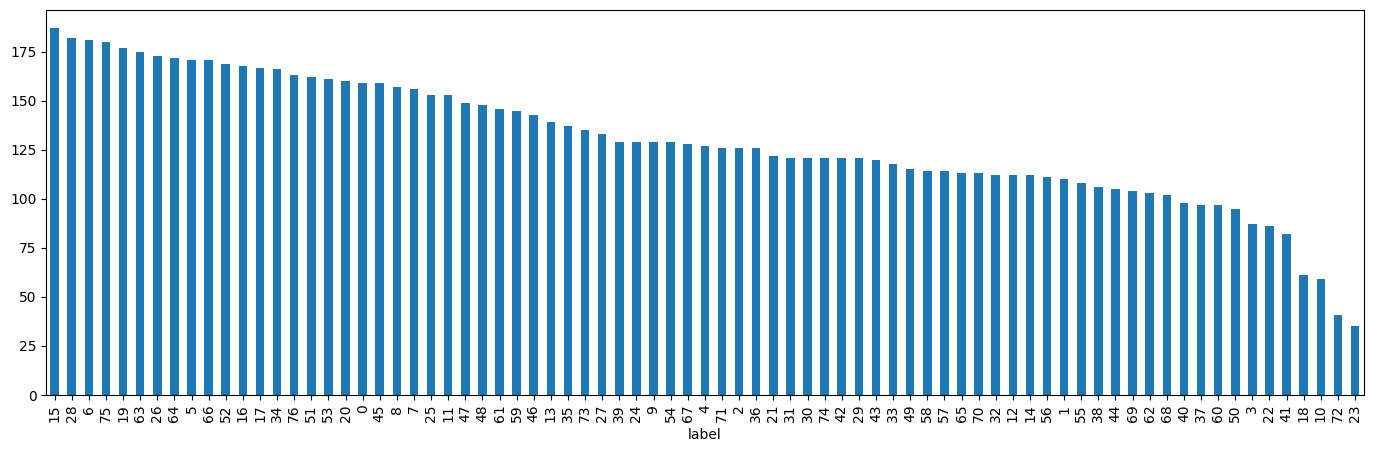

In [17]:
plt.figure(figsize = [17,5])
train_df['label'].value_counts().plot(kind = 'bar')

77 intent classes. Highest record is 175+, minimum times is 25+. Is this enough for training my model on?

<Axes: xlabel='label'>

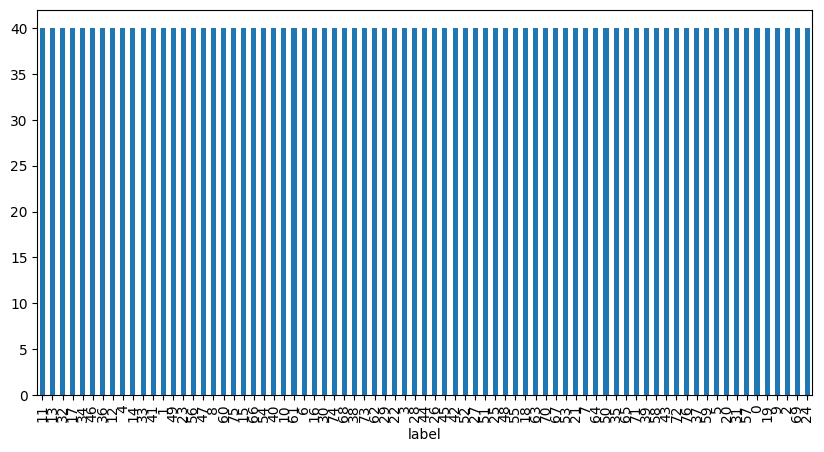

In [18]:
plt.figure(figsize = [10,5])
test_df['label'].value_counts().plot(kind = 'bar')

Well distributed test dataframe :)

In [21]:
for i in range(0,10):
    display(i,temp['text'][i])

0

'I am still waiting on my card?'

1

"What can I do if my card still hasn't arrived after 2 weeks?"

2

...

'What do I do if I still have not received my new card?'

8

'Does the package with my card have tracking?'

9

"I ordered my card but it still isn't here"

In [22]:
mx = 0
s = 0
for i in range(0,len(temp)):
    l = len(temp['text'][i])
    s += l
    if l > mx:
        mx = l
        max_index = i
print(f"Max length of the text = {mx}")
print(f"Avg length of the text = {s/len(temp):.2f}")

Max length of the text = 433
Avg length of the text = 58.24


In [23]:
temp['text'][max_index]

'Hearing back from us regarding your important verification results may take 10 minutes to one hour time.  If verification results do fail, double-check to make sure all of your images are clear --  make sure your photos have no glare or blurring. Note: These photos need to be readable as well.  You also need to be 18 years of age or older.  You must be a resident of Switzerland or the European Economic Area to open a new account.'

In [24]:
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

In [25]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(10003,) (10003,)
(3080,) (3080,)


In [26]:
X_train.head()

0                       I am still waiting on my card?
1    What can I do if my card still hasn't arrived ...
2    I have been waiting over a week. Is the card s...
3    Can I track my card while it is in the process...
4    How do I know if I will get my card, or if it ...
Name: text, dtype: object

In [ ]:
# # During training, key error was popping up.
# # after traintestsplit, pandas keeps the original indices, and may be like: [12, 45, 78, 102, 2950, ...]
# # later, on using self.intent_label[idx], idx is 1,2,3...., if 2950 is not found, KeyError is thrown

# X_train = X_train.reset_index(drop=True)
# X_test = X_test.reset_index(drop=True)

# y_intent_train = y_intent_train.reset_index(drop=True)
# y_intent_test = y_intent_test.reset_index(drop=True)

# # y_urgency_train = y_urgency_train.reset_index(drop=True)
# # y_urgency_test = y_urgency_test.reset_index(drop=True)


### Tokenization
We invoke Transformers here on out, for tokenization of our text(Ticket Description)

In [27]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [28]:
# Tokenizing

train_encodings = tokenizer(
    X_train.to_list(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [29]:
class TicketDataset(Dataset):
    def __init__(self, encodings, intent_labels):
        self.encodings = encodings
        self.intent_labels = intent_labels
 
    def __len__(self):
        return len(self.intent_labels)

    def __getitem__(self, idx):
        item = {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "intent_labels": torch.tensor(self.intent_labels[idx]),
         }
        return item

In [30]:
# Alternate way: Create an HF Dataset.
# This is a trade-off, we have lesser control, and its more difficult to customize later

# from datasets import Dataset

# dataset = Dataset.from_dict({
#     "input_ids": train_encodings["input_ids"],
#     "attention_mask": train_encodings["attention_mask"],
#     "intent_labels": y_intent_train,
#     "urgency_labels": y_urgency_train
# })

In [31]:
train_dataset = TicketDataset(
    train_encodings,
    y_train,
 )

test_dataset = TicketDataset(
    test_encodings,
    y_test,
 )

In [32]:
# Data Loader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

# Each batch is a tensor of value: (batch_size, sequence_length)

Work flow:
Text --> BERT Encoder --> [CLS token]Embedding  ->  Intent head

In [34]:
class MultiTaskBert(nn.Module):
    
    def __init__(self, num_intent_classes):
        super().__init__()
        
        self.bert = AutoModel.from_pretrained("bert-base-uncased")
        hidden_state = self.bert.config.hidden_size
        self.intent_classifier = nn.Linear(hidden_state, num_intent_classes)   #Taking in vec of dim hiddenstate and output of dim: no. of classes
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids = input_ids,
            attention_mask = attention_mask #(16,128)
        )                                                                      # dim is (16,128,768)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]                  # Extracting CLS token, which acts as summary repr. of the sentence
        intent_logits =  self.intent_classifier(cls_embeddings)
        return intent_logits

Loss and Optim claculation(Will prroceed to Training)

In [35]:
intent_loss_fn = nn.CrossEntropyLoss()

In [36]:
num_intent_classes = temp['label'].nunique()

model = MultiTaskBert(num_intent_classes)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [37]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device, '\n')
model.to(device)

cuda 



MultiTaskBert(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_aff

In [ ]:
# # -----------------Training-----------------
# epochs = 10

# for epoch in range(epochs):
#     model.train()
    
#     total_loss = 0
    
#     for batch in train_loader:
#         optimizer.zero_grad()
        
#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         intent_labels = batch["intent_labels"].to(device)
#         urgency_labels = batch["urgency_labels"].to(device)
        
#         intent_logits, urgency_logits = model(input_ids, attention_mask)
        
#         intent_loss = intent_loss_fn(intent_logits, intent_labels)
#         urgency_loss = urgency_loss_fn(urgency_logits, urgency_labels)
        
#         loss = (intent_loss + urgency_loss)/2
#         loss.backward()
        
#         optimizer.step()
#         total_loss += loss.item()
    
#     avg_loss = total_loss / len(train_loader)

#     print(f"\nEpoch: {epoch+1}/{epochs}")
#     print("Training loss:", avg_loss)

In [ ]:
# # ------------------VALIDATION-----------------
# import time
# start = time.time()

# epochs = 10

# for epoch in range(epochs):
 
#     model.eval()

#     intent_preds = []
#     intent_true = []
#     urgency_preds = []
#     urgency_true = []

#     with torch.no_grad():
#         for batch in test_loader:

#             input_ids = batch["input_ids"].to(device)
#             attention_mask = batch["attention_mask"].to(device)
#             intent_labels = batch["intent_labels"].to(device)
#             urgency_labels = batch["urgency_labels"].to(device)

#             intent_logits, urgency_logits = model(input_ids, attention_mask)

#             intent_pred = torch.argmax(intent_logits, dim=1)
#             urgency_pred = torch.argmax(urgency_logits, dim=1)

#             intent_preds.extend(intent_pred.cpu().numpy())
#             intent_true.extend(intent_labels.cpu().numpy())

#             urgency_preds.extend(urgency_pred.cpu().numpy())
#             urgency_true.extend(urgency_labels.cpu().numpy())


#     print(f"\nEpoch {epoch+1}/{epochs}")
#     print("Intent Acc:", round(accuracy_score(intent_true, intent_preds),4))
#     print("Intent F1:",f1_score(intent_true, intent_preds, average="weighted"))
#     print("Urgency Acc:", round(accuracy_score(urgency_true, urgency_preds),4)) 
#     print("Urgency F1:", f1_score(urgency_true, urgency_preds, average="weighted"))
# print(f"Time Taken = {time.time() - start}")

In [39]:
#----As per a reddit post, BERT works really well for 7-8 epochs, contrary to the original research that states 3-4-5 is enow

epochs = 8
for epoch in range(epochs):

    # ----------------- TRAINING -----------------
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        intent_labels = batch["intent_labels"].to(device)
 
        intent_logits = model(input_ids, attention_mask)

        intent_loss = intent_loss_fn(intent_logits, intent_labels)

        loss = intent_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ----------------- VALIDATION -----------------
    model.eval()

    intent_preds = []
    intent_true = []

    with torch.no_grad():
        for batch in test_loader:   

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            intent_labels = batch["intent_labels"].to(device)
 
            intent_logits = model(input_ids, attention_mask)

            intent_pred = torch.argmax(intent_logits, dim=1)
 
            intent_preds.extend(intent_pred.cpu().numpy())
            intent_true.extend(intent_labels.cpu().numpy())
 
    # ----------------- METRICS -----------------
    intent_acc = accuracy_score(intent_true, intent_preds)
    intent_f1 = f1_score(intent_true, intent_preds, average="weighted")
 
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("Training Loss:", round(avg_loss, 4))
    print("Intent Acc:", round(intent_acc, 4))
    print("Intent F1:", round(intent_f1, 4))


Epoch 1/8
Training Loss: 1.911
Intent Acc: 0.8688
Intent F1: 0.8658

Epoch 2/8
Training Loss: 0.4383
Intent Acc: 0.9146
Intent F1: 0.9147

Epoch 3/8
Training Loss: 0.2184
Intent Acc: 0.9195
Intent F1: 0.9195

Epoch 4/8
Training Loss: 0.1242
Intent Acc: 0.9045
Intent F1: 0.9032

Epoch 5/8
Training Loss: 0.0783
Intent Acc: 0.9221
Intent F1: 0.9224

Epoch 6/8
Training Loss: 0.0554
Intent Acc: 0.9169
Intent F1: 0.9169

Epoch 7/8
Training Loss: 0.0395
Intent Acc: 0.926
Intent F1: 0.926

Epoch 8/8
Training Loss: 0.0379
Intent Acc: 0.925
Intent F1: 0.9251


In [145]:
text = "I can't find my card, it must have run away help me get it back"
# tokenize it, convert to device
# send to the model
# model will send ouutput logits
# do softmax for probabilities, argmax for 1 concrete answer

model.eval()

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    logits = model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )
    
pred_class = torch.argmax(logits, dim=1).item()

probs = torch.softmax(logits, dim=1)
confidence = probs[0][pred_class].item()

predicted_intent = label_names[pred_class]

print(predicted_intent)
print("Confidence:", confidence)

lost_or_stolen_card
Confidence: 0.9411367774009705


In [146]:
# saving the model weights, tokenizer and label mappings
'''state_dict() saves only the weights as a dictionary of tensors; pure numbers, no Paths/Python dependencies.
You reconstruct the model separately and load weights into it.'''

import os
import json
os.makedirs("saved_model", exist_ok=True)

torch.save(model.state_dict(), "saved_model/bert_intent_classifier.pt")

tokenizer.save_pretrained("saved_model/tokenizer")

with open("saved_model/label_names.json", "w") as f:
    json.dump(label_names, f)